# 03. Word2Vec Modeling

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from gensim.models import Word2Vec
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
DATA_PATH = Path('../data/processed/reviews_dataset.csv')
df = pd.read_csv(DATA_PATH)
class_order = ['newbie', 'casual', 'engaged', 'veteran']

In [2]:
target = 'experience_class'
text_column = 'review'
base_metadata_columns = [
    'game', 
    'game_group', 
    'voted_up', 
    'votes_up', 
    'votes_funny', 
    'weighted_vote_score',
    'comment_count', 
    'steam_purchase', 
    'received_for_free',
    'written_during_early_access', 
    'author_num_games_owned',
    'author_num_reviews',
]

##### Функции для выбора среза данных

In [3]:
TOKEN_RE = re.compile(r"[a-zA-Z][a-zA-Z']+")


def subset_by_group(data, group):
    if group == 'all':
        return data.copy()
    return data[data['game_group'] == group].copy()


def tokenize(text):
    return TOKEN_RE.findall(str(text).lower())


def document_vector(tokens, model, vector_size):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if not vectors:
        return np.zeros(vector_size, dtype=np.float32)
    return np.mean(vectors, axis=0).astype(np.float32)


def vectorize_documents(tokenized_documents, model, vector_size):
    return np.vstack([
        document_vector(tokens, model, vector_size)
        for tokens in tokenized_documents
    ])

##### Функции для построения моделей

In [4]:
def build_metadata_preprocessor(metadata_columns):
    categorical_features = [
        column for column in [
            'game', 'game_group', 'voted_up', 'steam_purchase',
            'received_for_free', 'written_during_early_access',
        ]
        if column in metadata_columns
    ]
    numeric_features = [column for column in metadata_columns if column not in categorical_features]

    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_features),
        ('cat', Pipeline([
            ('to_object', FunctionTransformer(lambda values: values.astype(object), validate=False)),
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ], remainder='drop')


def build_word2vec(sentences, vector_size=100, window=5, min_count=2, sg=1, epochs=20):
    return Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=1,
        sg=sg,
        epochs=epochs,
        seed=42,
    )


def build_word2vec_logreg(X_train, y_train, vector_size=100):
    tokenized_train = X_train[text_column].map(tokenize).tolist()
    word2vec = build_word2vec(tokenized_train, vector_size=vector_size)
    X_train_word2vec = vectorize_documents(tokenized_train, word2vec, vector_size)
    model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
    model.fit(X_train_word2vec, y_train)
    return {
        'model': model,
        'word2vec': word2vec,
        'vector_size': vector_size,
    }


def predict_word2vec_logreg(bundle, X):
    tokenized = X[text_column].map(tokenize).tolist()
    X_word2vec = vectorize_documents(tokenized, bundle['word2vec'], bundle['vector_size'])
    return bundle['model'].predict(X_word2vec)


def build_word2vec_metadata_logreg(X_train, y_train, metadata_columns, vector_size=100):
    tokenized_train = X_train[text_column].map(tokenize).tolist()
    word2vec = build_word2vec(tokenized_train, vector_size=vector_size)
    X_train_word2vec = vectorize_documents(tokenized_train, word2vec, vector_size)

    metadata_preprocess = build_metadata_preprocessor(metadata_columns)
    X_train_metadata = metadata_preprocess.fit_transform(X_train[metadata_columns])
    X_train_features = sparse.hstack([sparse.csr_matrix(X_train_word2vec), X_train_metadata]).tocsr()

    model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
    model.fit(X_train_features, y_train)
    return {
        'model': model,
        'word2vec': word2vec,
        'metadata_preprocess': metadata_preprocess,
        'metadata_columns': metadata_columns,
        'vector_size': vector_size,
    }


def predict_word2vec_metadata_logreg(bundle, X):
    tokenized = X[text_column].map(tokenize).tolist()
    X_word2vec = vectorize_documents(tokenized, bundle['word2vec'], bundle['vector_size'])
    X_metadata = bundle['metadata_preprocess'].transform(X[bundle['metadata_columns']])
    X_features = sparse.hstack([sparse.csr_matrix(X_word2vec), X_metadata]).tocsr()
    return bundle['model'].predict(X_features)

##### Функция обучения и оценки моделей

In [5]:
def evaluate_group(data, group_name):
    group_df = subset_by_group(data, group_name)
    metadata_columns = [column for column in base_metadata_columns if column in group_df.columns]
    X = group_df[[text_column] + metadata_columns].copy()
    y = group_df[target].astype(str)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_train[[text_column]], y_train)
    dummy_predictions = dummy.predict(X_test[[text_column]])

    word2vec_only = build_word2vec_logreg(X_train, y_train)
    word2vec_only_predictions = predict_word2vec_logreg(word2vec_only, X_test)

    word2vec_metadata = build_word2vec_metadata_logreg(X_train, y_train, metadata_columns)
    word2vec_metadata_predictions = predict_word2vec_metadata_logreg(word2vec_metadata, X_test)

    predictions_by_model = {
        'dummy_most_frequent': dummy_predictions,
        'word2vec_only': word2vec_only_predictions,
        'word2vec_metadata': word2vec_metadata_predictions,
    }
    fitted_models = {
        'dummy_most_frequent': dummy,
        'word2vec_only': word2vec_only,
        'word2vec_metadata': word2vec_metadata,
    }

    rows = []
    for model_name, predictions in predictions_by_model.items():
        rows.append({
            'game_group': group_name,
            'model': model_name,
            'accuracy': accuracy_score(y_test, predictions),
            'macro_f1': f1_score(y_test, predictions, average='macro'),
        })

    results = pd.DataFrame(rows).sort_values('macro_f1', ascending=False)
    best_name = results.iloc[0]['model']
    return {
        'group_name': group_name,
        'data': group_df,
        'results': results,
        'best_name': best_name,
        'best_model': fitted_models[best_name],
        'best_predictions': predictions_by_model[best_name],
        'X_test': X_test,
        'y_test': y_test,
    }

##### Обучение моделей и сводная таблица метрик

In [6]:
group_runs = {group: evaluate_group(df, group) for group in ['all', 'offline', 'competitive']}
all_results = pd.concat([run['results'] for run in group_runs.values()], ignore_index=True)
all_results.sort_values(['game_group', 'macro_f1'], ascending=[True, False])

,game_group,model,accuracy,macro_f1
0,all,word2vec_metadata,0.495984,0.495621
1,all,word2vec_only,0.426372,0.414324
2,all,dummy_most_frequent,0.371486,0.135432
6,competitive,word2vec_metadata,0.425406,0.421590
7,competitive,word2vec_only,0.357459,0.348296
8,competitive,dummy_most_frequent,0.311669,0.118806
3,offline,word2vec_metadata,0.512225,0.481799
4,offline,word2vec_only,0.426650,0.400591
5,offline,dummy_most_frequent,0.480440,0.162263


##### Сравнение `macro_f1` моделей по группам

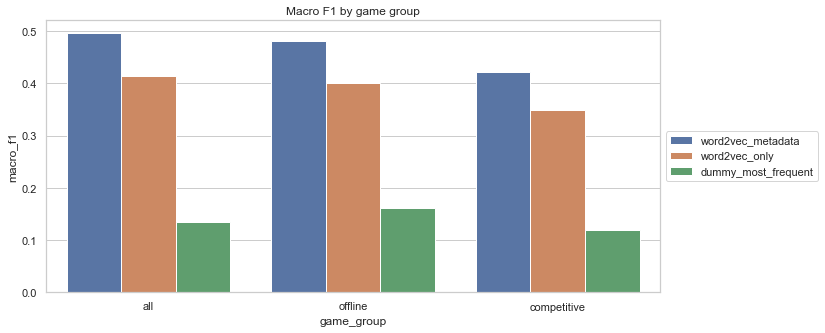

In [7]:
plt.figure(figsize=(11, 5))
sns.barplot(data=all_results, x='game_group', y='macro_f1', hue='model')
plt.title('Macro F1 by game group')
plt.xlabel('game_group')
plt.ylabel('macro_f1')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

##### Confusion matrix для лучшей модели в каждом срезе

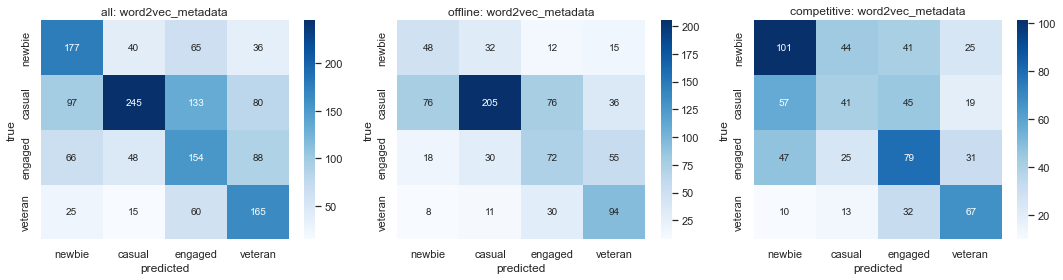

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group_name in zip(axes, ['all', 'offline', 'competitive']):
    run = group_runs[group_name]
    matrix = confusion_matrix(run['y_test'], run['best_predictions'], labels=class_order)
    sns.heatmap(matrix, annot=True, fmt='d', xticklabels=class_order, yticklabels=class_order, cmap='Blues', ax=ax)
    ax.set_title(f"{group_name}: {run['best_name']}")
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
plt.tight_layout()
plt.show()

##### Classification report для каждого среза

In [9]:
for group_name in ['all', 'offline', 'competitive']:
    run = group_runs[group_name]
    print(f"\n{group_name}: {run['best_name']}")
    print(classification_report(run['y_test'], run['best_predictions'], labels=class_order, zero_division=0))


all: word2vec_metadata
              precision    recall  f1-score   support

      newbie       0.48      0.56      0.52       318
      casual       0.70      0.44      0.54       555
     engaged       0.37      0.43      0.40       356
     veteran       0.45      0.62      0.52       265

    accuracy                           0.50      1494
   macro avg       0.50      0.51      0.50      1494
weighted avg       0.53      0.50      0.50      1494


offline: word2vec_metadata
              precision    recall  f1-score   support

      newbie       0.32      0.45      0.37       107
      casual       0.74      0.52      0.61       393
     engaged       0.38      0.41      0.39       175
     veteran       0.47      0.66      0.55       143

    accuracy                           0.51       818
   macro avg       0.48      0.51      0.48       818
weighted avg       0.56      0.51      0.52       818


competitive: word2vec_metadata
              precision    recall  f1-score   

##### Примеры ошибок модели

In [10]:
error_tables = []
for group_name in ['all', 'offline', 'competitive']:
    run = group_runs[group_name]
    errors = run['X_test'].copy()
    errors['game_group_view'] = group_name
    errors['true_class'] = run['y_test'].values
    errors['predicted_class'] = run['best_predictions']
    errors = errors[errors['true_class'] != errors['predicted_class']]
    error_tables.append(errors[['game_group_view', 'game', 'true_class', 'predicted_class', 'review']].head(3))

pd.concat(error_tables, ignore_index=True)

,game_group_view,game,true_class,predicted_class,review
0,all,Apex Legends,veteran,engaged,"Dollar Store Servers, Hackers Rampant despite ..."
1,all,Red Dead Redemption 2,casual,engaged,Amazing game amazing graphics. Only thing is i...
2,all,Counter-Strike 2,casual,newbie,Counter-Strike still hits a little different f...
3,offline,BioShock Infinite,casual,newbie,"I want you to think of the term ""Narrative Leg..."
4,offline,Red Dead Redemption 2,engaged,veteran,"Best game ever, the characters feel real, the ..."
5,offline,Horizon Zero Dawn Complete Edition,veteran,engaged,I got stressed a little completing the gold ch...
6,competitive,War Thunder,casual,engaged,The Mikoyan-Gurevich MiG-15 was a Soviet jet f...
7,competitive,Counter-Strike 2,newbie,casual,"Guys, do a favor to yourself and never play pr..."
8,competitive,War Thunder,engaged,casual,I highly recommend progressing through this ga...


##### Близкие слова в обученном Word2Vec

In [11]:
probe_words = ['grind', 'toxic', 'story', 'boss', 'hours', 'cheaters', 'fun']
word2vec = group_runs['all']['best_model']['word2vec']

nearest_terms = []
for word in probe_words:
    if word not in word2vec.wv:
        nearest_terms.append({'word': word, 'nearest_words': '<not in vocabulary>'})
        continue
    nearest = ', '.join(term for term, score in word2vec.wv.most_similar(word, topn=8))
    nearest_terms.append({'word': word, 'nearest_words': nearest})

pd.DataFrame(nearest_terms)

,word,nearest_words
0,grind,"revolvers, misserable, leaderboards, saps, top..."
1,toxic,"welcoming, racist, positivity, slump, salty, a..."
2,story,"storyline, intriguing, gripping, infinite's, c..."
3,boss,"fights, bosses, defeat, fight, valkerie, chapt..."
4,hours,"hrs, logged, thousands, dumped, approximately,..."
5,cheaters,"hackers, suspicion, bots, closet, cheating, fl..."
6,fun,"enjoyable, funner, ol', noteworthy, osts, expe..."
